# Distributed ML Training

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics(list1, list2, name1, name2, metrics):
    avg1 = [np.mean(metric) for metric in list1]
    avg2 = [np.mean(metric) for metric in list2]

    n = len(metrics)
    bar_width = 0.3    # width of each bar
    inner_gap = 0.1    # gap between K8S and HPK bars within group
    group_gap = 0.5    # gap between different worker groups

    # Compute x positions with extra space between groups
    x_positions = []
    base = 0
    for _ in range(n):
        # Two bars per group, spaced by inner_gap
        x_positions.append((base, base + bar_width + inner_gap))
        base += bar_width * 2 + inner_gap + group_gap

    bars1_x = [pos[0] for pos in x_positions]
    bars2_x = [pos[1] for pos in x_positions]

    fig, ax = plt.subplots(figsize=(10, 6))

    K8S_color = (0.2, 0.45, 1)
    HPK_color = (0.9, 0.25, 0.25)

    bars1 = ax.bar(bars1_x, avg1, bar_width, label=name1, color=K8S_color, capsize=5)
    bars2 = ax.bar(bars2_x, avg2, bar_width, label=name2, color=HPK_color, capsize=5)

    # Annotate bars with their values
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=10)

    # Set x ticks in the middle of each group (between two bars)
    mid_points = [(a + b) / 2 for a, b in zip(bars1_x, bars2_x)]
    ax.set_xticks(mid_points)
    ax.set_xticklabels(metrics)

    ax.set_ylabel('Time (minutes)')
    ax.set_title(f'Distributed ML Training: {name1} vs {name2} (GPU)')
    ax.legend()

    ax.set_ylim(0, 5.5)

    plt.tight_layout()
    plt.savefig("bert_eval.pdf", format='pdf', bbox_inches='tight')
    plt.show()


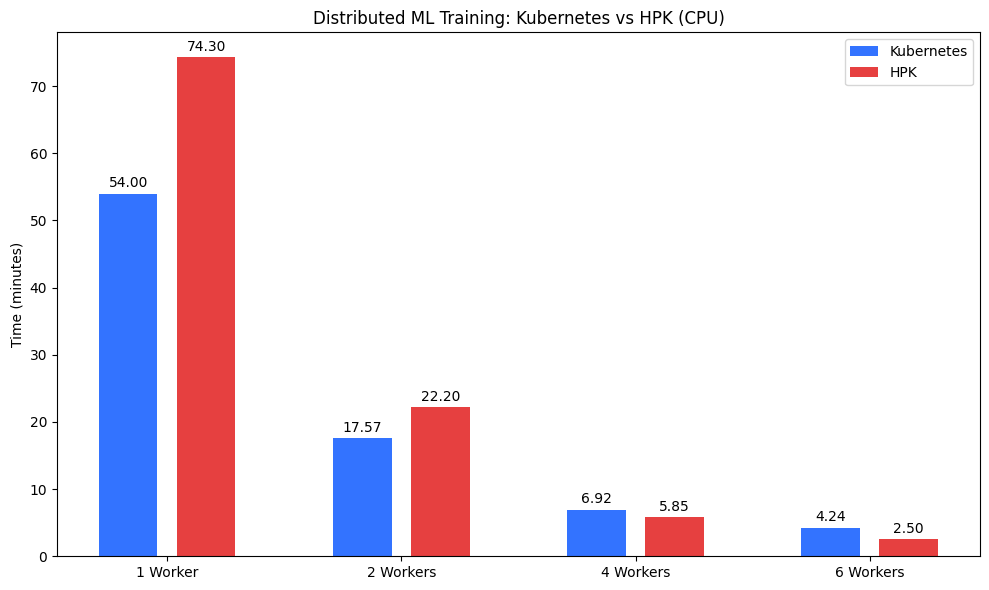

In [4]:
# cluster configuration:
# 1 worker, 2 workers, 4 workers, 6 workers
# 4 CPUs, 16gb RAM per worker

K8S1 = [54.6, 54, 53.4]
K8S2 = [17, 17.8, 17.9]
K8S4 = [6.85, 7, 6.9]
K8S6 = [4.26, 4.2, 4.25]

K8S_metrics = [K8S1, K8S2, K8S4, K8S6]

HPK1 = [75.1, 71.3, 76.5]
HPK2 = [21.7, 22.8, 22.1]
HPK4 = [5.9, 5.8, 5.85]
HPK6 = [2.5, 2.5, 2.5]

HPK_metrics = [HPK1, HPK2, HPK4, HPK6]

metrics_names = ['1 Worker', '2 Workers', '4 Workers', '6 Workers']

plot_metrics(K8S_metrics, HPK_metrics, 'Kubernetes', 'HPK', metrics_names)

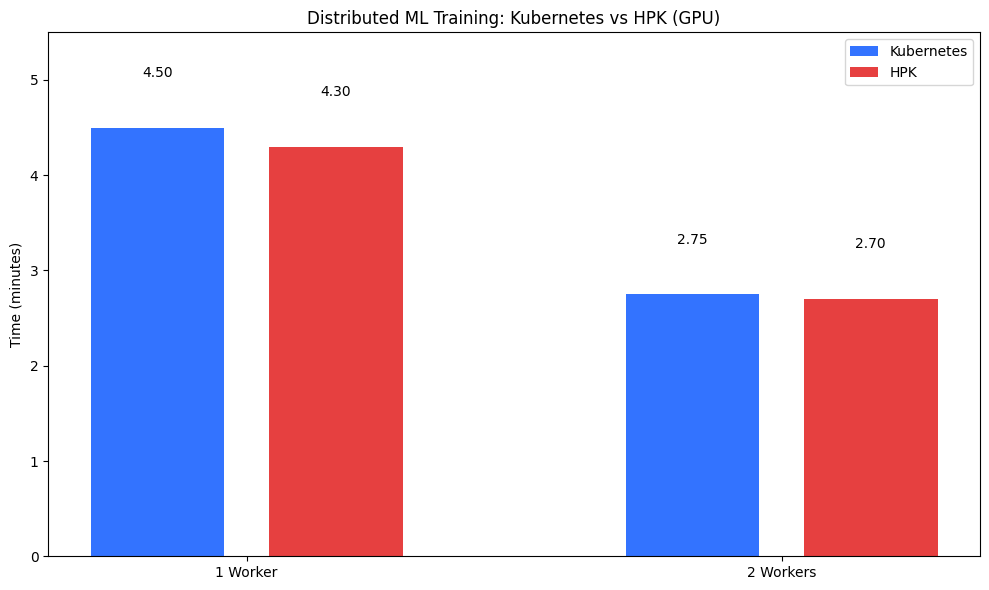

In [11]:
# cluster configuration:
# 1 worker, 2 workers, 4 workers, 6 workers
# 4 CPUs, 16gb RAM per worker

K8SGPU1 = [4.5, 4.5, 4.5]
K8SGPU2 = [2.6, 3, 2.65]

K8S_metrics = [K8SGPU1, K8SGPU2]

HPKGPU1 = [4.3, 4.3, 4.3]
HPKGPU2 = [2.7, 2.7, 2.7]

HPK_metrics = [HPKGPU1, HPKGPU2]

metrics_names = ['1 Worker', '2 Workers']

plot_metrics(K8S_metrics, HPK_metrics, 'Kubernetes', 'HPK', metrics_names)